# **Stroke Predictions Data Analysis**

The main aim of this analysis is to understand how each variable in this dataset affects the target variable "Stroke"

## Objectives

* Find and download dataset from Kaggle
* Clean Data: Deal with outliers, missing and/or duplicated entries
* Encoding: Encode any categorical data  before data visualisation 
* Visualisation: Plotting Univariate and Multivariate analysis
* Statistical Analysis: Identifying the significance betweent variable relationship

## Inputs

* Stroke Predictions dataset which can be found [here](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

## Outputs

* cleaned_dataset 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [12]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\DA2_Assessment'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [13]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [14]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project'

# Extract Data

Section 1 content

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path
data_path = Path("../Data/Raw_Data/healthcare-dataset-stroke-data.csv")
df = pd.read_csv(data_path)
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [5]:
list(df.columns)

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'stroke']

In [6]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


(5110, 12)

In [7]:
df.duplicated().sum()

0

In [10]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


---

# Section 2: Transform

**Missing Values Analysis**

In [11]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [12]:
# Fill missing values in 'bmi' column with the median value to handle missing data
df['bmi'].fillna(df['bmi'].median(), inplace=True)

Instead of removing the rows with missing BMI values, I chose to fill them using the median BMI. This decision was based on the severe class imbalance in the dataset: only 249 patients had a stroke compared to 4,861 who did not.

If I removed rows with missing BMI values, I would risk deleting a meaningful portion of the already small stroke class.  
While removing a few non‑stroke rows would not significantly affect the dataset, losing even a small number of stroke cases would significantly reduce the I have on stroke pateitns which will make analysis that much harder to draw meaningful conclusions.This would also negatively impact the machine learning stage, because the model would have even fewer positive examples to learn from, making it harder to correctly identify stroke cases in unseen data.

Using median imputation allows me to retain as much data as possible without introducing bias and will preserve the overall distribution shape.

In [13]:
df['bmi'].isnull().sum()

0

**Outlier Detection**

Outliers are visually detected by plotting a boxplot of each variable. Bmi and avg_glucose_level are the only numerical variables that contain outliers 

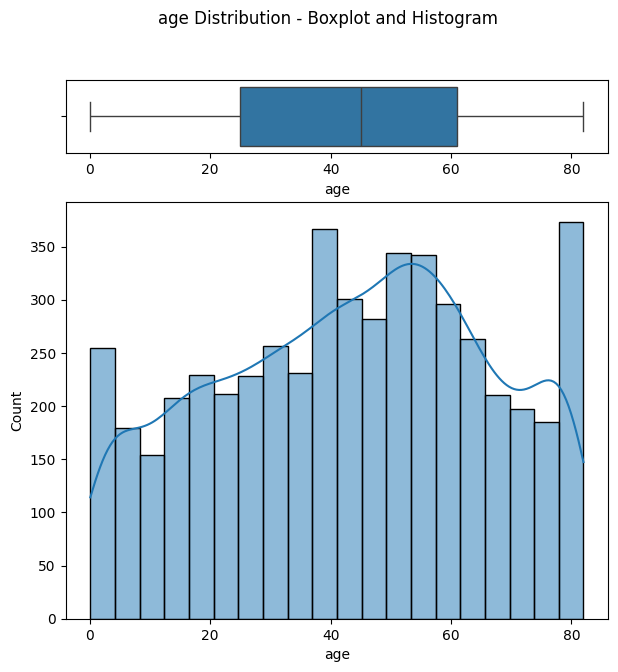

This is the range where a data point is not an outlier: from -29.0 to 115.0




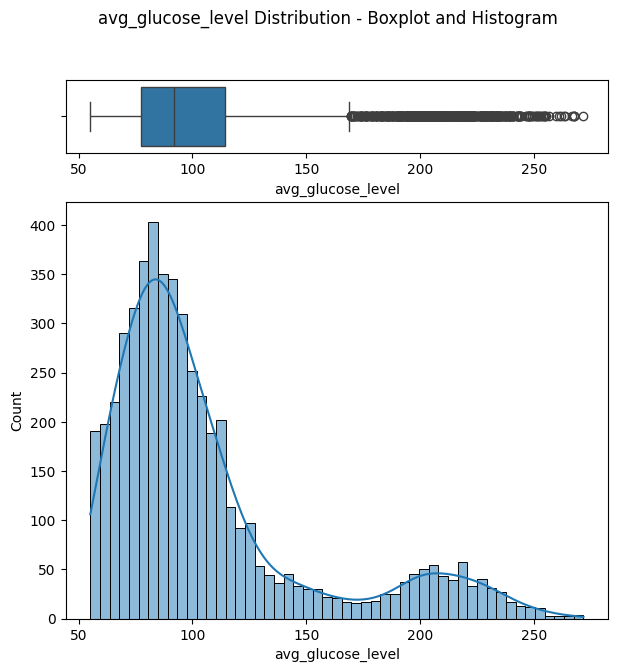

This is the range where a data point is not an outlier: from 21.98 to 169.36




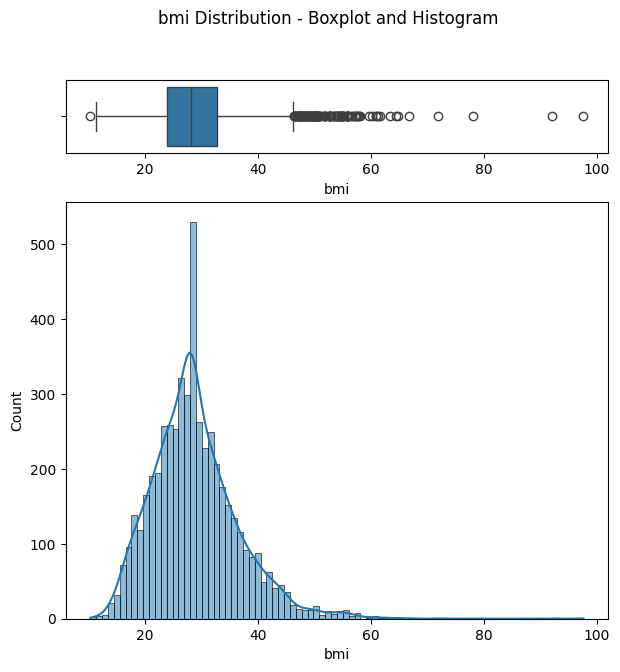

This is the range where a data point is not an outlier: from 10.3 to 46.3




In [14]:
def plot_histogram_and_boxplot(df):
    # Define the numeric columns to analyse for outliers
    selected_cols = ['age', 'avg_glucose_level', 'bmi']
    
    # Loop through each column and create visualisation
    for col in selected_cols:
        # Create subplots with boxplot on top and histogram below
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), gridspec_kw={"height_ratios": (.15, .85)})
        
        # Plot boxplot to visualise outliers
        sns.boxplot(data=df, x=col, ax=axes[0])
        
        # Plot histogram with KDE curve to show distribution
        sns.histplot(data=df, x=col, kde=True, ax=axes[1])
        
        # Add title to the figure
        fig.suptitle(f"{col} Distribution - Boxplot and Histogram")
        plt.show()

        # Calculate IQR-based outlier boundaries for numeric columns only
        if pd.api.types.is_numeric_dtype(df[col]):
            # Calculate Q1, Q3, and IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # Calculate lower and upper bounds (outliers are beyond ±1.5*IQR from quartiles)
            lower = (Q1 - 1.5 * IQR).round(2)
            upper = (Q3 + 1.5 * IQR).round(2)
            
            # Print the outlier range for interpretation
            print(f"This is the range where a data point is not an outlier: from {lower} to {upper}")
            print("\n")
plot_histogram_and_boxplot(df)

**Winsorizer - Capping Outliers**

To handle the outliers, I used the Feature Engine Winsorizer, which replaces extreme values with the nearest value within the acceptable range, as shown in the plots above. This method allows me to keep all rows in the dataset while reducing the influence of extreme values. Because I want to preserve as much data as possible, Winsorization was an appropriate choice.

The outliers were replaced as keeping them will skew the data and can lead to inflated or deflaed values which could reduce the accuracy of my data analysis.

By capping the outliers instead of deleting rows, I avoid losing valuable observations—especially important in a dataset where stroke cases are already rare. 

---

In [15]:
# Apply IQR-based Winsorizer to cap outliers in 'bmi' and 'avg_glucose_level' columns
# This replaces values beyond 1.5*IQR from the quartiles with the upper/lower bounds

from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('winsorizer_iqr', Winsorizer(capping_method = 'iqr', fold=1.5, tail='both', variables = ['bmi','avg_glucose_level']))
])
df_transformed = pipeline.fit_transform(df)
df_transformed.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,169.3575,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.0900,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.3900,22.8,never smoked,1


In [16]:
# Display the upper bound thresholds used by the Winsorizer to cap outliers in the right tail
# This shows the maximum values that outliers are capped to for 'bmi' and 'avg_glucose_level'

pipeline['winsorizer_iqr'].right_tail_caps_

{'bmi': 46.29999999999999, 'avg_glucose_level': 169.35750000000002}

In [17]:
# Display the lower bound thresholds used by the Winsorizer to cap outliers in the left tail
# This shows the minimum values that outliers are capped to for 'bmi' and 'avg_glucose_level'

pipeline['winsorizer_iqr'].left_tail_caps_

{'bmi': 10.300000000000006, 'avg_glucose_level': 21.977500000000006}

========Before Outlier Treatment========


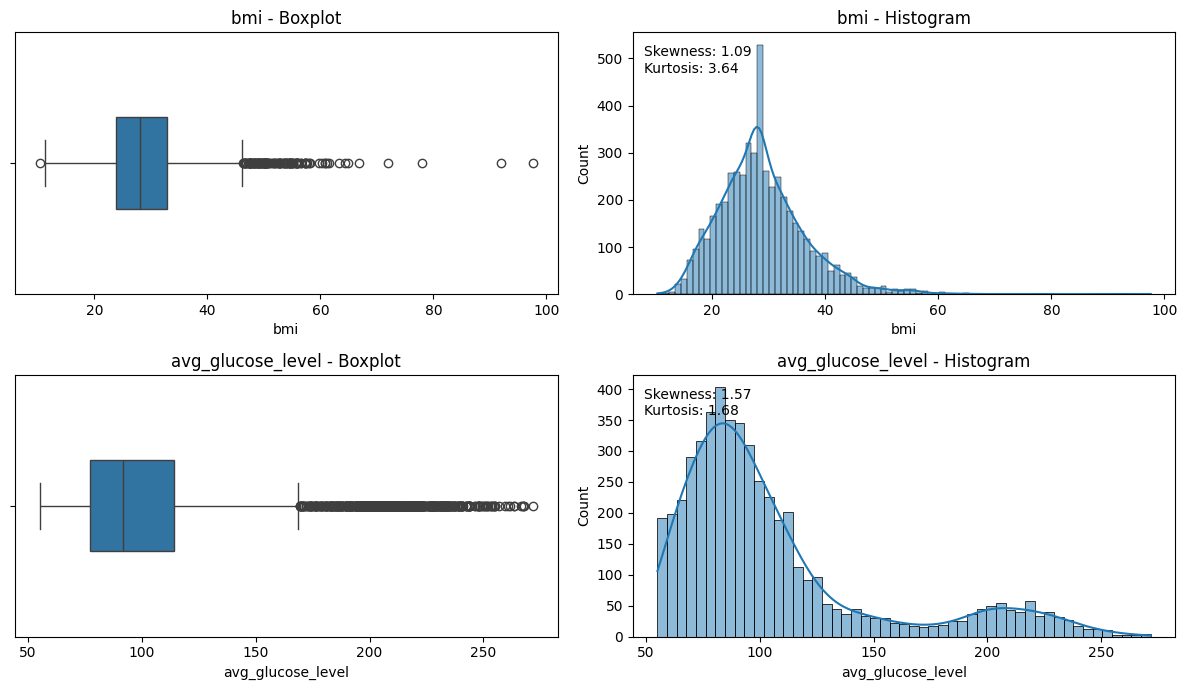

========After Outlier Treatment========


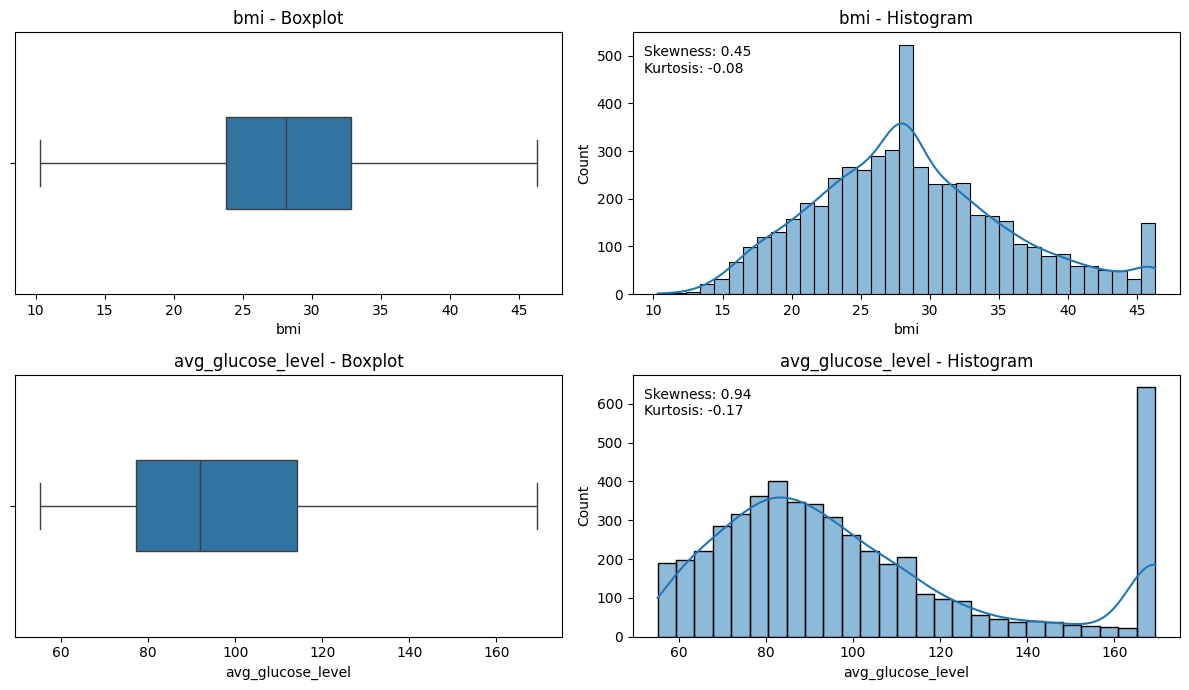

In [18]:
# Visualize the distribution and outliers of 'bmi' and 'avg_glucose_level' before applying Winsorizer
# Shows boxplots and histograms with skewness and kurtosis statistics for comparison with post-treatment data

print("========Before Outlier Treatment========")
selected_cols = ['bmi', 'avg_glucose_level']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df[col].skew():.2f}\nKurtosis: {df[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

print("========After Outlier Treatment========")
selected_cols = ['bmi', 'avg_glucose_level']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

for idx, col in enumerate(selected_cols):
    box_ax = axes[idx, 0]
    hist_ax = axes[idx, 1]
    sns.boxplot(data=df_transformed, x=col, ax=box_ax, width=0.35)
    sns.histplot(data=df_transformed, x=col, kde=True, ax=hist_ax)
    box_ax.set_title(f"{col} - Boxplot")
    hist_ax.set_title(f"{col} - Histogram")
    hist_ax.text(
        0.02,
        0.95,
        f"Skewness: {df_transformed[col].skew():.2f}\nKurtosis: {df_transformed[col].kurtosis():.2f}",
        transform=hist_ax.transAxes,
        va='top'
    )

plt.tight_layout()
plt.show()

In [19]:
# Keep only numeric columns so strings/categorical values don't break stats
numeric_df = df_transformed.select_dtypes(include='number')

ser_skew = numeric_df.skew()
ser_skew.name = 'skewness'

ser_kurt = numeric_df.kurtosis()
ser_kurt.name = 'kurtosis'

summary_stats = numeric_df.describe()
summary_stats.loc['skewness'] = ser_skew
summary_stats.loc['kurtosis'] = ser_kurt

summary_stats

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,100.996204,28.690411,0.048728
std,21161.721625,22.612647,0.296607,0.226063,33.214738,7.120858,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,169.357500,46.300000,1.000000
skewness,-0.019913,-0.137059,2.715392,3.947244,0.935354,0.449248,4.193284
kurtosis,-1.212368,-0.991010,5.375456,13.586052,-0.173527,-0.076852,15.589736


## Encoding ##

**OneHotEncoder**

All categorical data that are string are converted to numerical values this will become useful during the machine learning stage also for analysis

In [22]:
from feature_engine.encoding import OneHotEncoder

In order to know which variable to apply the OneHotEncoder Ordinal Enconder each catergorical variable's unique values need to be know 

In [23]:
df_transformed['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [24]:
df_transformed['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [25]:
df_transformed['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [26]:
# One-hot encode the 'sex' and 'smoker' columns while keeping the original categorical data.
# This allows us to use the encoded columns for modelling without losing the original labels for interpretation or categorical data visualization.

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')

encoded = ohe.fit_transform(df_transformed[['gender','ever_married','Residence_type']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['gender', 'ever_married','Residence_type']))

df_final = pd.concat([df_transformed, encoded_df], axis=1)
df_final.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,ever_married_Yes,Residence_type_Urban
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1,1.0,0.0,1.0,1.0
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1,0.0,0.0,1.0,0.0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1,1.0,0.0,1.0,0.0
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1,0.0,0.0,1.0,1.0
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1,0.0,0.0,1.0,0.0
5,56669,Male,81.0,0,0,Yes,Private,Urban,169.3575,29.0,formerly smoked,1,1.0,0.0,1.0,1.0
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.0900,27.4,never smoked,1,1.0,0.0,1.0,0.0
7,10434,Female,69.0,0,0,No,Private,Urban,94.3900,22.8,never smoked,1,0.0,0.0,0.0,1.0


**Ordinal Encoder**

In [27]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()

encoded = oe.fit_transform(df[['work_type', 'smoking_status']])
encoded_df = pd.DataFrame(encoded, columns=['work_type_encoded', 'smoking_status_encoded'], index=df.index)

df_final = df_final.join(encoded_df)
df_final.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,ever_married_Yes,Residence_type_Urban,work_type_encoded,smoking_status_encoded
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1,1.0,0.0,1.0,1.0,2.0,1.0
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1,1.0,0.0,1.0,0.0,2.0,2.0
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1,0.0,0.0,1.0,1.0,2.0,3.0
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0


In [28]:
df_final['weight_category'] = pd.cut(
    df_final['bmi'],
    bins=[0, 18.5, 24.9, 29.9,39.9, float('inf')],
    labels=['Underweight', 'Healthy', 'Overweight', 'Obese', 'severely Obese']
)
df_final.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,ever_married_Yes,Residence_type_Urban,work_type_encoded,smoking_status_encoded,weight_category
0,9046,Male,67.0,0,1,Yes,Private,Urban,169.3575,36.6,formerly smoked,1,1.0,0.0,1.0,1.0,2.0,1.0,Obese
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,169.3575,28.1,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0,Overweight
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.9200,32.5,never smoked,1,1.0,0.0,1.0,0.0,2.0,2.0,Obese
3,60182,Female,49.0,0,0,Yes,Private,Urban,169.3575,34.4,smokes,1,0.0,0.0,1.0,1.0,2.0,3.0,Obese
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,169.3575,24.0,never smoked,1,0.0,0.0,1.0,0.0,3.0,2.0,Healthy
5,56669,Male,81.0,0,0,Yes,Private,Urban,169.3575,29.0,formerly smoked,1,1.0,0.0,1.0,1.0,2.0,1.0,Overweight
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.0900,27.4,never smoked,1,1.0,0.0,1.0,0.0,2.0,2.0,Overweight
7,10434,Female,69.0,0,0,No,Private,Urban,94.3900,22.8,never smoked,1,0.0,0.0,0.0,1.0,2.0,2.0,Healthy


NHS website was used to identify which bmi belonged to each weight category the information can be found [here](https://www.nhs.uk/conditions/obesity/)


In [29]:
df_final = df_final[
    [
        # Health conditions
        "hypertension",
        "heart_disease",

        # BMI + weight category
        "bmi", "weight_category",
        
        # Glucose + stroke
        "avg_glucose_level",
        "stroke",
        
        # Demographics
        "gender", "gender_Male", "gender_Other",
        "age",
        
        
        # Marital status
        "ever_married", "ever_married_Yes",
        
        # Residence
        "Residence_type", "Residence_type_Urban",
        
        # Work type
        "work_type", "work_type_encoded",
        
        
    ]
]
df_final.head(8)


,hypertension,heart_disease,bmi,weight_category,avg_glucose_level,stroke,gender,gender_Male,gender_Other,age,ever_married,ever_married_Yes,Residence_type,Residence_type_Urban,work_type,work_type_encoded
0,0,1,36.6,Obese,169.3575,1,Male,1.0,0.0,67.0,Yes,1.0,Urban,1.0,Private,2.0
1,0,0,28.1,Overweight,169.3575,1,Female,0.0,0.0,61.0,Yes,1.0,Rural,0.0,Self-employed,3.0
2,0,1,32.5,Obese,105.9200,1,Male,1.0,0.0,80.0,Yes,1.0,Rural,0.0,Private,2.0
3,0,0,34.4,Obese,169.3575,1,Female,0.0,0.0,49.0,Yes,1.0,Urban,1.0,Private,2.0
4,1,0,24.0,Healthy,169.3575,1,Female,0.0,0.0,79.0,Yes,1.0,Rural,0.0,Self-employed,3.0
5,0,0,29.0,Overweight,169.3575,1,Male,1.0,0.0,81.0,Yes,1.0,Urban,1.0,Private,2.0
6,1,1,27.4,Overweight,70.0900,1,Male,1.0,0.0,74.0,Yes,1.0,Rural,0.0,Private,2.0
7,0,0,22.8,Healthy,94.3900,1,Female,0.0,0.0,69.0,No,0.0,Urban,1.0,Private,2.0


**Q-Q Plot - Understanding Data Distribution**

In [ ]:
 # Create a count plot to visualize the distribution of each categorical variable
for col in df_transformed.select_dtypes(include='object').columns:
    print(f"{df[col].value_counts()} \n\n")

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 


ever_married
Yes    3353
No     1757
Name: count, dtype: int64 


work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 


Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 




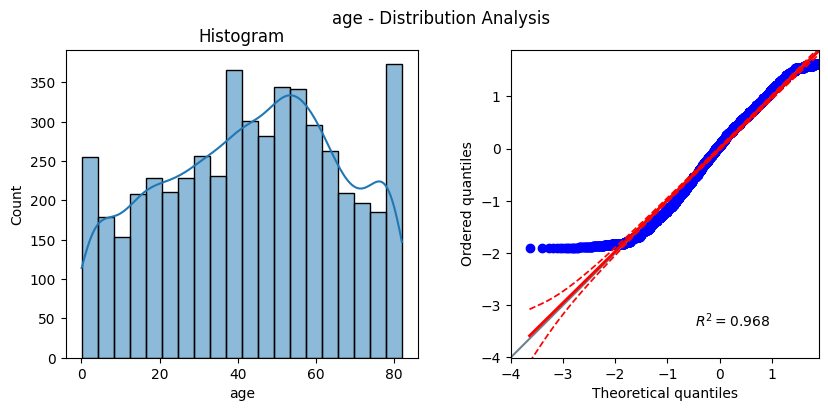

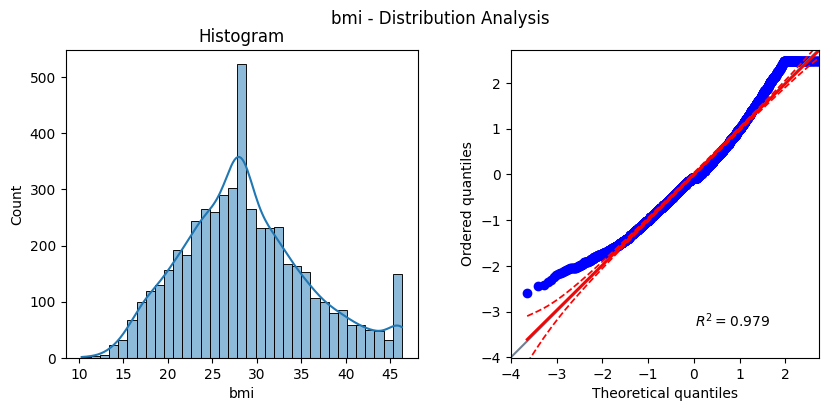

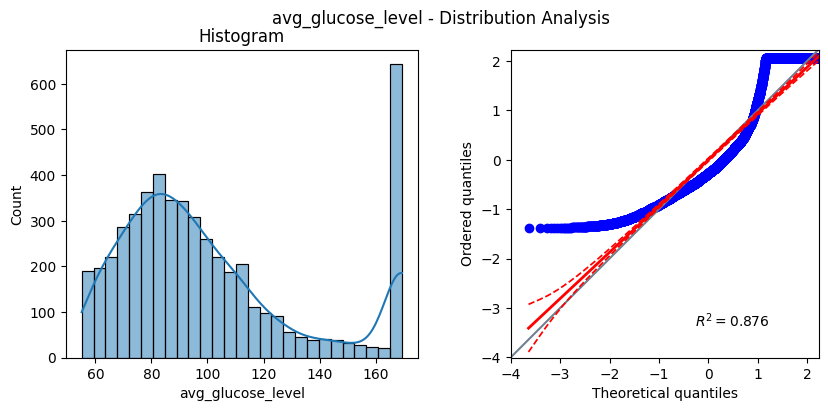

In [31]:
import pingouin as pg

# Only loop through specific numeric columns for Q-Q plots
numeric_cols = ['age', 'bmi', 'avg_glucose_level']

for col in numeric_cols:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    sns.histplot(data=df_final, x=col, kde=True, ax=axes[0])
    axes[0].set_title("Histogram")
    pg.qqplot(df_final[col], dist='norm', ax=axes[1])
    fig.suptitle(f"{col} - Distribution Analysis")
    plt.show()
    print('\n')

**Age**

The Histogram and Q-Q plot for Age show the data is very close the the 'normal line' indicating the age variable is approximately normally distributed. The R2 value being very close to one also shoes how close to normal the data is. This will be explored futher during the datv visualisation set using pg.normality(). 

**Bmi**

This histogram shows that most people's age is clustered arounf 25 - 30. The R2 values is higher here indicating the overall fit is strong however the data is still slighlty right skewed due to the end datapoint  increasing therefore the data isn't classed as normally distributed.

**Avg_glucose_level**

Its quite ecident from looking that the values are not normally distrbuted which is also evident form the loewr R2 value fo 0.876. This shows a moderate fit. Gluose is the least noramlly distributed variable.

In [30]:
df_final.to_csv("Cleaned_Data.csv", index=False)